In [1]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [2]:
#Making The Dataset
df = pd.DataFrame()
df["x1"] = [1,2,3,4,5,6,6,7,9,9]
df["x2"] = [5,3,6,8,1,9,5,8,9,2]
df["label"] = [1,1,0,1,0,1,0,1,0,0]

In [3]:
#Assigning Weights
df["weights"] = 1/df.shape[0]

In [4]:
#Visualising the dataframe
df

,x1,x2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


d:\project\sample_project\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


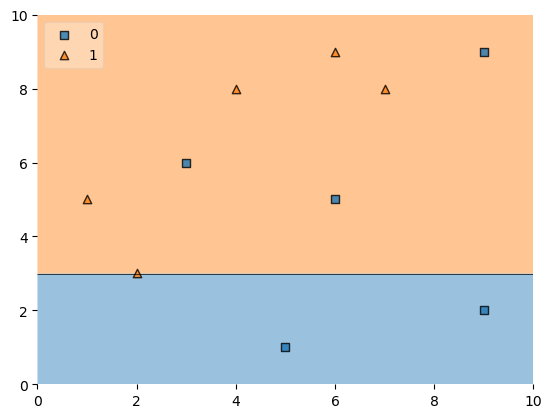

In [5]:
#Training a Decision Tree with max depth = 1 and predicting the values. (Decision Stump)
def trainer(df):
    x = df[["x1","x2"]]
    y = df["label"]
    dt = DecisionTreeClassifier(max_depth=1)
    dt.fit(x,y)
    df["predicted"] = dt.predict(x)
    plot_decision_regions(x.values,y.values,clf = dt,legend=2)
trainer(df)

In [6]:
#Points where predicted and real outputs dont match
df['label'][df["label"]!=df["predicted"]]

2    0
6    0
8    0
Name: label, dtype: int64

In [7]:
#Function for Updating weights
def update_weights(df):
    error = sum(df['weights'][df["label"]!=df["predicted"]])
    alpha1 = 0.5*np.log((1-error)/(error+0.0000000000000001))
    for i in range(df.shape[0]):
        if df.loc[i,"label"]!=df.loc[i,"predicted"]:
            df.loc[i,"new_weights"] = df.loc[i,"weights"]*np.exp(alpha1)
        else:
            df.loc[i,"new_weights"] = df.loc[i,"weights"]*np.exp(-alpha1)
    df['new_weights'] = df["new_weights"]/df["new_weights"].sum()
update_weights(df)

In [8]:
#Assigning ranges
def assign_range(df):
    df["range_upper"] = np.cumsum(df["new_weights"]) 
    df["range_lower"] = np.cumsum(df["new_weights"])-df["new_weights"]
assign_range(df)

In [9]:
df

,x1,x2,label,weights,predicted,new_weights,range_upper,range_lower
0,1,5,1,0.1,1,0.071429,0.071429,0.000000
1,2,3,1,0.1,1,0.071429,0.142857,0.071429
2,3,6,0,0.1,1,0.166667,0.309524,0.142857
3,4,8,1,0.1,1,0.071429,0.380952,0.309524
4,5,1,0,0.1,0,0.071429,0.452381,0.380952
5,6,9,1,0.1,1,0.071429,0.523810,0.452381
6,6,5,0,0.1,1,0.166667,0.690476,0.523810
7,7,8,1,0.1,1,0.071429,0.761905,0.690476
8,9,9,0,0.1,1,0.166667,0.928571,0.761905
9,9,2,0,0.1,0,0.071429,1.000000,0.928571


In [10]:
def assigned(df):
    li = []
    for i in range(df.shape[0]):
        li.append(np.random.random())
    df["assigned"] = 0
    for i in li:
        row = df[(i<df["range_upper"]) & (i>df["range_lower"])].index[0]
        df.loc[row,"assigned"]+=1
assigned(df)

In [11]:
df

,x1,x2,label,weights,predicted,new_weights,range_upper,range_lower,assigned
0,1,5,1,0.1,1,0.071429,0.071429,0.000000,1
1,2,3,1,0.1,1,0.071429,0.142857,0.071429,1
2,3,6,0,0.1,1,0.166667,0.309524,0.142857,1
3,4,8,1,0.1,1,0.071429,0.380952,0.309524,0
4,5,1,0,0.1,0,0.071429,0.452381,0.380952,0
5,6,9,1,0.1,1,0.071429,0.523810,0.452381,1
6,6,5,0,0.1,1,0.166667,0.690476,0.523810,4
7,7,8,1,0.1,1,0.071429,0.761905,0.690476,0
8,9,9,0,0.1,1,0.166667,0.928571,0.761905,1
9,9,2,0,0.1,0,0.071429,1.000000,0.928571,1


In [12]:
new_df = df.loc[df.index.repeat(df["assigned"])].reset_index(drop = True)

In [13]:
new_df

,x1,x2,label,weights,predicted,new_weights,range_upper,range_lower,assigned
0,1,5,1,0.1,1,0.071429,0.071429,0.000000,1
1,2,3,1,0.1,1,0.071429,0.142857,0.071429,1
2,3,6,0,0.1,1,0.166667,0.309524,0.142857,1
3,6,9,1,0.1,1,0.071429,0.523810,0.452381,1
4,6,5,0,0.1,1,0.166667,0.690476,0.523810,4
5,6,5,0,0.1,1,0.166667,0.690476,0.523810,4
6,6,5,0,0.1,1,0.166667,0.690476,0.523810,4
7,6,5,0,0.1,1,0.166667,0.690476,0.523810,4
8,9,9,0,0.1,1,0.166667,0.928571,0.761905,1
9,9,2,0,0.1,0,0.071429,1.000000,0.928571,1


d:\project\sample_project\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


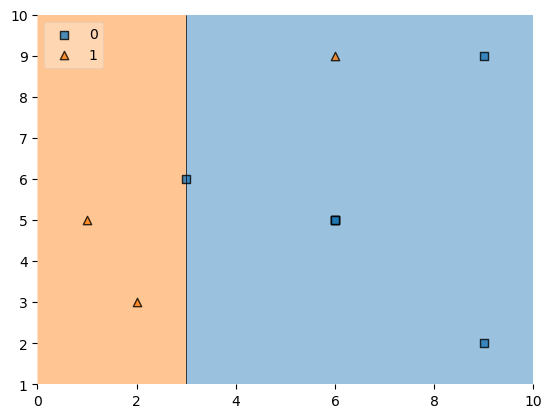

In [14]:
#Repeating process on the second dataset
trainer(new_df)
update_weights(new_df)
assign_range(new_df)
assigned(new_df)

In [15]:
new_df_2 = df.loc[df.index.repeat(new_df["assigned"])].reset_index(drop = True)

d:\project\sample_project\env\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


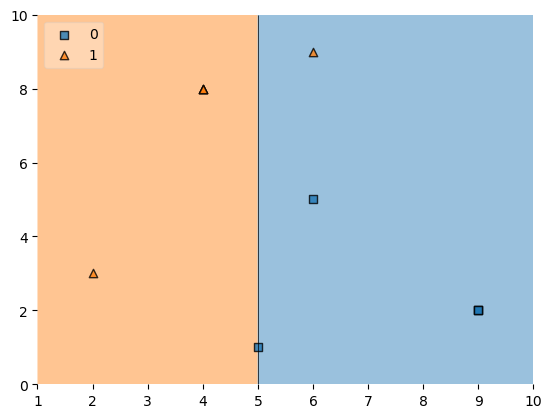

In [16]:
#Repeating process on the third dataset
trainer(new_df_2)
update_weights(new_df_2)
assign_range(new_df_2)
assigned(new_df_2)

In [17]:
new_df_2

,x1,x2,label,weights,predicted,new_weights,range_upper,range_lower,assigned
0,2,3,1,0.1,1,0.055556,0.055556,0.000000,0
1,4,8,1,0.1,1,0.055556,0.111111,0.055556,0
2,4,8,1,0.1,1,0.055556,0.166667,0.111111,0
3,4,8,1,0.1,1,0.055556,0.222222,0.166667,1
4,5,1,0,0.1,0,0.055556,0.277778,0.222222,0
5,6,9,1,0.1,0,0.500000,0.777778,0.277778,4
6,6,5,0,0.1,0,0.055556,0.833333,0.777778,0
7,9,2,0,0.1,0,0.055556,0.888889,0.833333,2
8,9,2,0,0.1,0,0.055556,0.944444,0.888889,2
9,9,2,0,0.1,0,0.055556,1.000000,0.944444,1
